In [48]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Analysis of Inference Output


In [49]:
modelname = 'fullmodel'
inferencename = 'mb8_fullmodel'
inferencepath = f'S:/pools/t/T-IDP-Projekte-u-Vorlesungen/Meteoblue/QRF/Data/FINAL/Inference/{inferencename}/{inferencename}.csv'
inferencefile = pd.read_csv(inferencepath, delimiter=',')
inferencefile['datetime'] = pd.to_datetime(inferencefile['datetime'])

def make_lists(x):
    """ Comes in the form [val1 val2 val3] and must be converted to a list with floats"""
    vals = x.replace('[','').replace(']','')
    vals = ' '.join(vals.split())
    vals = vals.split(' ')

    return [float(val) for val in vals]

def extract_prediction(x: pd.DataFrame):
    """ Extracts the prediction and upper / lower confidence intervals from the prediction list"""
    preds = []
    uCI = []
    lCI = []
    for row in range(len(x)):
        lCI.append(x['Prediction'].iloc[row][0])
        preds.append(x['Prediction'].iloc[row][1])
        uCI.append(x['Prediction'].iloc[row][2])
    return preds, uCI, lCI

inferencefile['Prediction'] = inferencefile['Prediction'].apply(make_lists)
inferencefile['Predicted Temperature'], inferencefile['Upper Boundary'], inferencefile['Lower Boundary'] = extract_prediction(inferencefile)

Optional: load model test and inference files

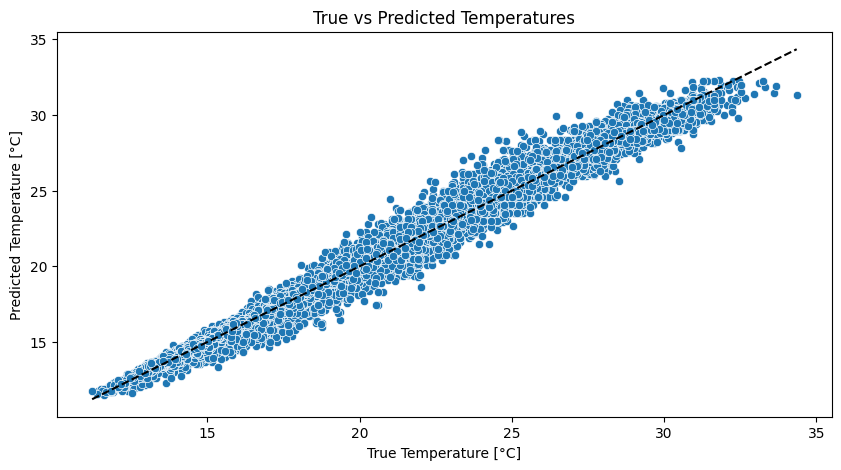

In [50]:
ax, fig = plt.subplots(figsize=(10,5))
ax = sns.scatterplot(data=inferencefile, x='True Temperature', y='Predicted Temperature')
ax.set(xlabel='True Temperature [°C]', ylabel='Predicted Temperature [°C]', title='True vs Predicted Temperatures')
# 45° line
bounds = [inferencefile['True Temperature'].min(), inferencefile['True Temperature'].max()]
ax.plot(bounds, bounds, color='black', linestyle='--')

## Error Metrics

In [51]:
inferencefile['Error'] = inferencefile['True Temperature'] - inferencefile['Predicted Temperature']
rmse = np.sqrt(np.mean(inferencefile['Error']**2))
print('TRUE - PREDICTED [°C]')
print('------------------------------------')
print(f'RMSE: {rmse:.2f}')
print(f'Mean Error: {np.mean(inferencefile["Error"]):.2f}')
print(f'Max Error: {np.max(inferencefile["Error"]):.2f}')
print(f'Min Error: {np.min(inferencefile["Error"]):.2f}')
print(f'Median Error: {np.median(inferencefile["Error"]):.2f}')
print(f'Standard Deviation: {np.std(inferencefile["Error"]):.2f}')

TRUE - PREDICTED [°C]
------------------------------------
RMSE: 0.53
Mean Error: -0.05
Max Error: 3.36
Min Error: -3.80
Median Error: -0.07
Standard Deviation: 0.53


C:\Users\ushe\AppData\Local\Temp\ipykernel_14228\1625824895.py:1: UserWarning: Ignoring `ax`; jointplot is a figure-level function.
  g = sns.jointplot(ax = ax, data=inferencefile, x='datetime', y='Error')


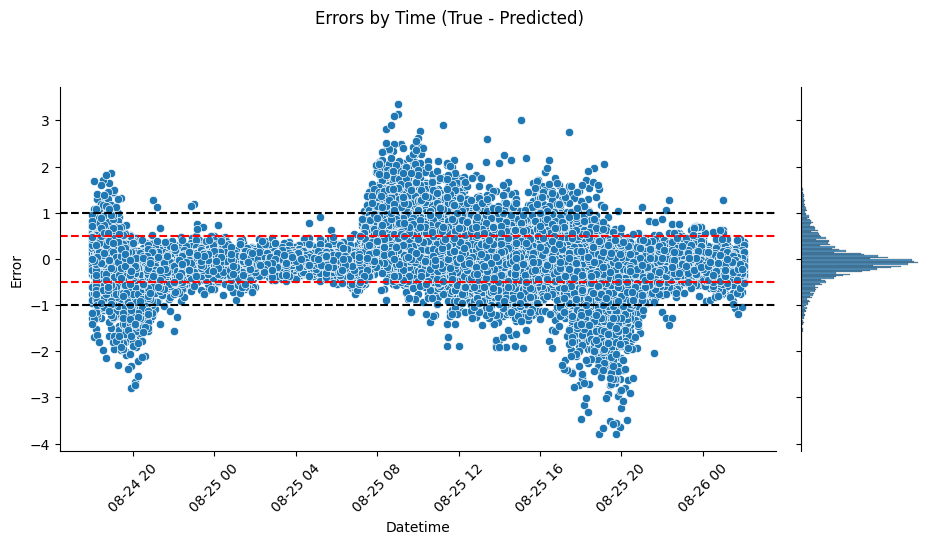

In [52]:
g = sns.jointplot(ax = ax, data=inferencefile, x='datetime', y='Error')
g.figure.set_figheight(5)
g.figure.set_figwidth(10)
g.ax_marg_x.remove()
plt.xticks(rotation=45)
g.set_axis_labels('Datetime', 'Error')
g.figure.suptitle('Errors by Time (True - Predicted)')
# Add horizontal lines
plt.axhline(0.5, color='red', linestyle='--')
plt.axhline(-0.5, color='red', linestyle='--')
plt.axhline(1, color='black', linestyle='--')
plt.axhline(-1, color='black', linestyle='--')

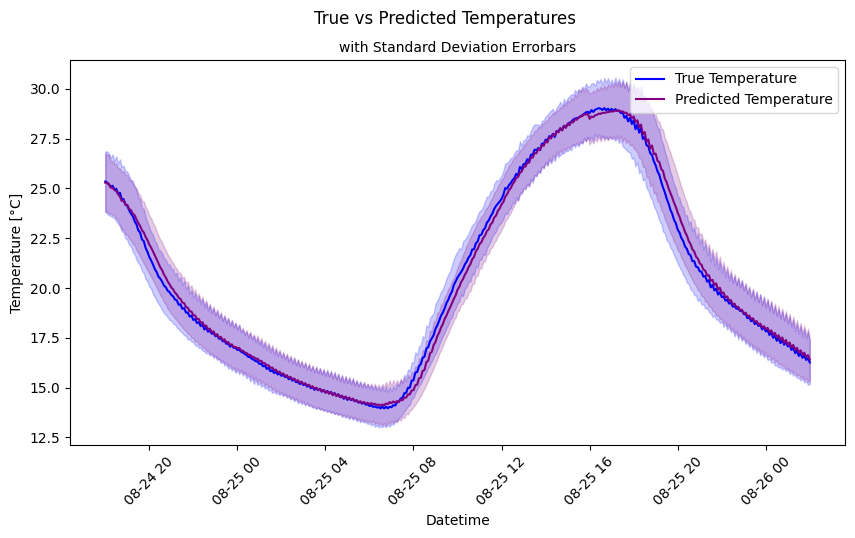

In [53]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=inferencefile, x='datetime', y='True Temperature', label='True Temperature', color='blue', errorbar='sd')
sns.lineplot(data=inferencefile, x='datetime', y='Predicted Temperature', label='Predicted Temperature', color='purple', errorbar='sd')
plt.xlabel('Datetime')
plt.ylabel('Temperature [°C]')
plt.title('with Standard Deviation Errorbars', fontsize=10)
# plt.title('with Standard Deviation Errorbars')
plt.suptitle('True vs Predicted Temperatures')
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Distribution Comparison
Training set is loaded to compare the training set temperature (target) distribution to the inference distribution.

In [54]:
testpath = f'S:/pools/t/T-IDP-Projekte-u-Vorlesungen/Meteoblue/QRF/Data/FINAL/Training/{modelname}/{modelname}.csv'
# testfile = pd.read_csv(testpath, delimiter=',')
# testfile['datetime'] = pd.to_datetime(testfile['datetime'])

trainingsetpath = testpath.split('.csv')[0] + '_trainingset.csv'
trainingfile = pd.read_csv(trainingsetpath, delimiter=',')
trainingfile['datetime'] = pd.to_datetime(trainingfile['datetime'])
        

# testfile['Prediction'] = testfile['Prediction'].apply(make_lists)
# testfile['Predicted Temperature'], testfile['Upper Boundary'], testfile['Lower Boundary'] = extract_prediction(testfile)

[Text(0.5, 0, 'Temperature [°C]'),
 Text(0, 0.5, 'Density'),
 Text(0.5, 1.0, 'Temperature Distribution in Training and Test Set mb8_fullmodel (RMSE: 0.53)')]

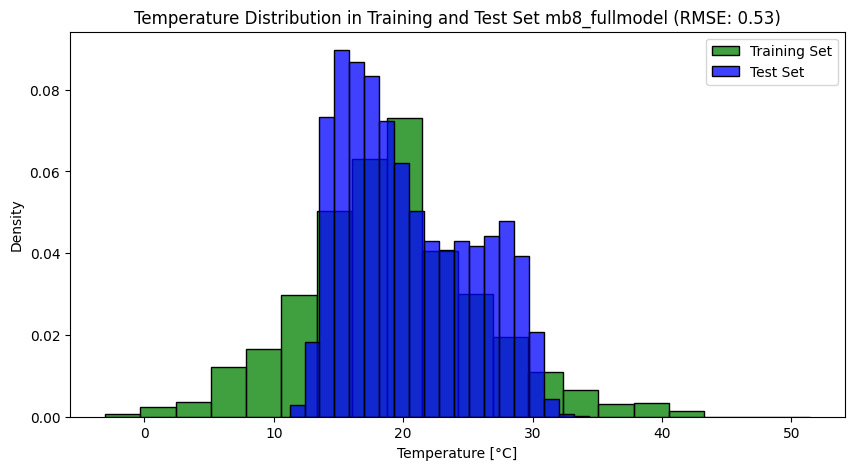

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(trainingfile['Temperature'], color='green', stat='density', bins=20)
sns.histplot(inferencefile['True Temperature'], color='blue', stat='density', bins=20)
ax.legend(['Training Set', 'Test Set'])
ax.set(xlabel='Temperature [°C]', ylabel='Density', title=f'Temperature Distribution in Training and Test Set {inferencename} (RMSE: {rmse:.2f})')

### Kolmogorov-Smirnov Test
The one-sample test compares the underlying distribution F(x) of a sample against a given distribution G(x). The two-sample test compares the underlying distributions of two independent samples. Both tests are valid only for continuous distributions.

Null-Hypothesis: the distributions are the same

In [56]:
from scipy.stats import kstest

results = kstest(trainingfile['Temperature'], inferencefile['True Temperature'])
print(results)
if results[1] > 0.05:
    print('INTERPRETATION: The distributions of training and tested data are the same')
else:
    print('INTERPRETATION: The distributions of training and tested data are different')

KstestResult(statistic=0.16219715176793648, pvalue=0.0, statistic_location=13.42, statistic_sign=1)
INTERPRETATION: The distributions of training and tested data are different
